# Customer Churn Prediction & Customer Segmentation

## 06 — Customer Segmentation & Business Profiling

### Objective

The churn model answers:

> **Which customers are likely to churn?**

Segmentation answers a different question:

> **What type of customers do we have?**

The goal of this notebook is to create meaningful customer groups using customer behaviour and value-related characteristics.

We will:

1. Prepare segmentation features
2. Scale the data
3. Compare a reasonable range of cluster counts
4. Use the Elbow method and Silhouette Score
5. Train the final KMeans model
6. Profile each segment
7. Give the segments business-friendly descriptions
8. Connect the segments with churn behaviour
9. Convert the clustering output into actionable business recommendations

### Important principle

We will **not use the Churn target to create the clusters**.

Churn is used later to understand the risk profile of each segment.

This prevents the segmentation from simply becoming another version of the churn classifier.

# 1. Import libraries

We use:

- Pandas for data preparation and profiling
- NumPy for numerical operations
- Matplotlib and Seaborn for visual analysis
- StandardScaler for putting features on comparable scales
- KMeans for customer clustering
- Silhouette Score for evaluating cluster separation

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2. Load the raw customer data

We start from the original dataset so that the segmentation process is independent of the churn model.

The raw data remains untouched.

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Customer-Churn.csv"
)

df = pd.read_csv(RAW_DATA_PATH)

print(
    f"Dataset loaded: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)

df.head()

Dataset loaded: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Clean the data required for segmentation

`TotalCharges` is stored as text in the raw dataset.

We convert it into a numeric variable before using it for customer profiling.

For the small number of records where the original value is blank, we reconstruct the value using:

```text
TotalCharges = tenure × MonthlyCharges
```

This is consistent with the preparation logic used earlier in the project.

In [3]:
working_df = df.copy()

working_df["TotalCharges"] = pd.to_numeric(
    working_df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

missing_total_charges = (
    working_df["TotalCharges"].isna()
)

working_df.loc[
    missing_total_charges,
    "TotalCharges"
] = (
    working_df.loc[
        missing_total_charges,
        "tenure"
    ]
    * working_df.loc[
        missing_total_charges,
        "MonthlyCharges"
    ]
)

print(
    "Missing TotalCharges after cleaning:",
    working_df["TotalCharges"].isna().sum()
)

Missing TotalCharges after cleaning: 0


# 4. Create segmentation features

Segmentation should be based on meaningful customer characteristics.

For this project, we use:

- `tenure` → how long the customer has stayed
- `MonthlyCharges` → current monthly customer value/cost
- `TotalCharges` → cumulative monetary relationship
- `ServiceCount` → breadth of services adopted

We also create:

- `AverageMonthlySpend`
- `IsNewCustomer`

However, we will be selective about which variables actually enter KMeans.

### Why?

Too many correlated variables can distort distance-based clustering.

For example, `TotalCharges` is naturally related to tenure and monthly charges.

Therefore, we will inspect the candidate features before deciding the final clustering inputs.

In [4]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

working_df["ServiceCount"] = 0

for column in service_columns:
    working_df["ServiceCount"] += (
        working_df[column] == "Yes"
    ).astype(int)

working_df["AverageMonthlySpend"] = (
    working_df["TotalCharges"]
    / working_df["tenure"].clip(lower=1)
)

working_df["IsNewCustomer"] = (
    working_df["tenure"] <= 12
).astype(int)

segmentation_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "AverageMonthlySpend"
]

segmentation_data = working_df[
    segmentation_features
].copy()

segmentation_data.describe().round(2)

,tenure,MonthlyCharges,TotalCharges,ServiceCount,AverageMonthlySpend
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.04,64.70
std,24.56,30.09,2266.79,1.85,30.27
min,0.00,18.25,0.00,0.00,0.00
25%,9.00,35.50,398.55,0.00,35.65
50%,29.00,70.35,1394.55,2.00,70.30
75%,55.00,89.85,3786.60,3.00,90.17
max,72.00,118.75,8684.80,6.00,121.40


# 5. Check the candidate segmentation features

Before clustering, we inspect the relationships between the candidate variables.

This is important because KMeans is distance-based.

Highly correlated variables can cause one underlying behaviour to receive too much influence.

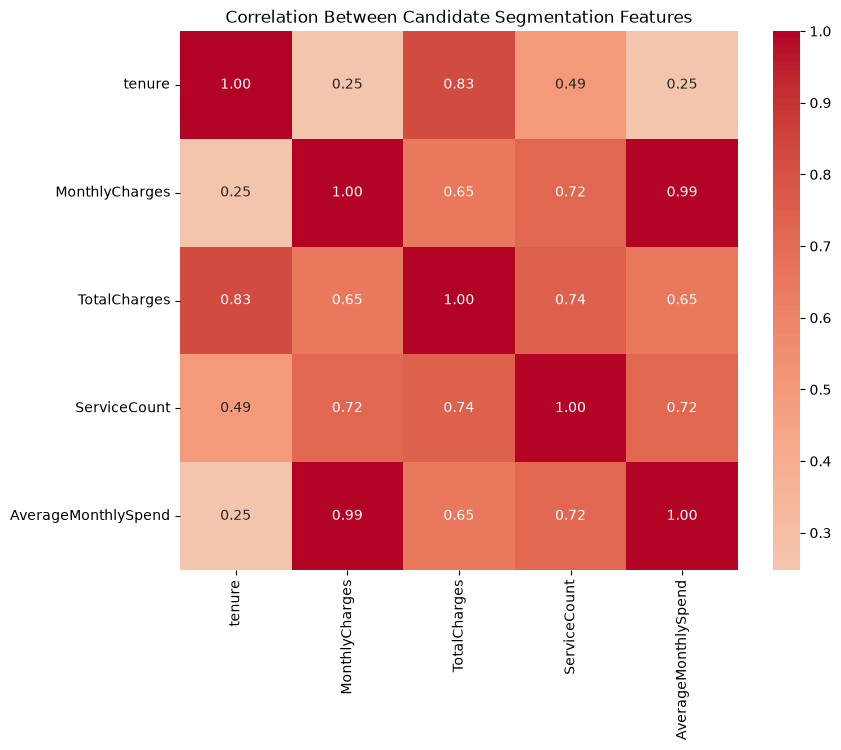

In [5]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    segmentation_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Candidate Segmentation Features"
)

plt.show()

### Feature decision

`TotalCharges` is strongly connected to tenure and monthly charges because it represents cumulative spending.

For the main clustering model, we therefore use a more behaviour-oriented feature set:

- `tenure`
- `MonthlyCharges`
- `ServiceCount`

This gives the clusters a clearer business interpretation:

> **How long has the customer stayed, how much are they currently paying, and how deeply are they using the service portfolio?**

`TotalCharges` and `AverageMonthlySpend` will still be used later for segment profiling.

In [6]:
clustering_features = [
    "tenure",
    "MonthlyCharges",
    "ServiceCount"
]

X_segmentation = working_df[
    clustering_features
].copy()

X_segmentation.head()

,tenure,MonthlyCharges,ServiceCount
0,1,29.85,1
1,34,56.95,2
2,2,53.85,2
3,45,42.30,3
4,2,70.70,0


# 6. Scale the clustering features

KMeans uses distance to determine which customers belong together.

Without scaling, a feature with a larger numerical range could dominate the clustering process.

For example:

- tenure might range from 0–72
- MonthlyCharges might range from roughly 20–120
- ServiceCount ranges from 0–6

Standardization puts them on a comparable scale.

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_segmentation
)

print(
    "Scaled feature matrix shape:",
    X_scaled.shape
)

Scaled feature matrix shape: (7043, 3)


# 7. Find a reasonable number of clusters

We do not choose `k` randomly.

We compare a practical range of cluster counts using:

1. **Inertia / Elbow Method**
2. **Silhouette Score**

The goal is not to blindly maximize one metric.

We want a cluster count that is:

- reasonably separated
- stable enough to interpret
- useful for business decisions

In [8]:
cluster_counts = range(2, 9)

inertia_values = []

silhouette_values = []

for number_of_clusters in cluster_counts:

    model = KMeans(
        n_clusters=number_of_clusters,
        random_state=42,
        n_init=10
    )

    cluster_labels = model.fit_predict(
        X_scaled
    )

    inertia_values.append(
        model.inertia_
    )

    silhouette_values.append(
        silhouette_score(
            X_scaled,
            cluster_labels
        )
    )

cluster_evaluation = pd.DataFrame({
    "Number_of_Clusters": list(cluster_counts),
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values
})

cluster_evaluation.round(4)

,Number_of_Clusters,Inertia,Silhouette_Score
0,2,10782.4537,0.4163
1,3,7295.4199,0.3968
2,4,5615.0759,0.4042
3,5,4647.4290,0.3641
4,6,3812.3919,0.3704
5,7,3376.8921,0.3841
6,8,3017.7675,0.3917


## 8. Elbow method

The elbow plot shows how much within-cluster variation decreases as more clusters are added.

After a certain point, adding another cluster gives progressively smaller improvement.

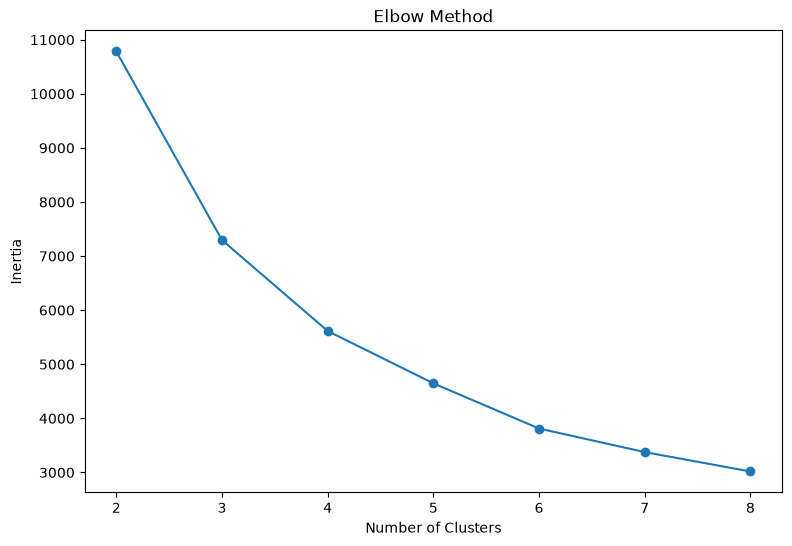

In [9]:
plt.figure(figsize=(9, 6))

plt.plot(
    cluster_evaluation["Number_of_Clusters"],
    cluster_evaluation["Inertia"],
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

## 9. Silhouette Score

Silhouette Score measures how well-separated the clusters are.

Higher values generally indicate that observations are closer to their own cluster than to neighbouring clusters.

We use it as supporting evidence rather than as the only decision rule.

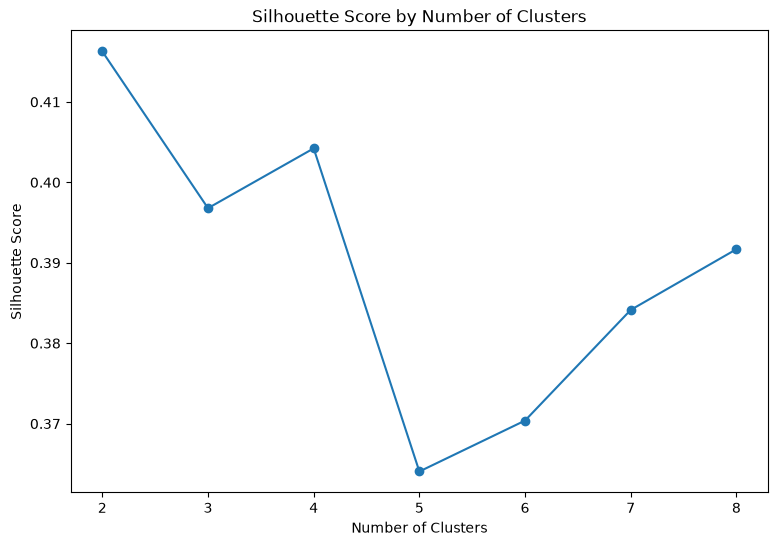

In [10]:
plt.figure(figsize=(9, 6))

plt.plot(
    cluster_evaluation["Number_of_Clusters"],
    cluster_evaluation["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [11]:
best_silhouette_row = cluster_evaluation.loc[
    cluster_evaluation["Silhouette_Score"].idxmax()
]

suggested_cluster_count = int(
    best_silhouette_row["Number_of_Clusters"]
)

print(
    "Highest silhouette score suggests:",
    suggested_cluster_count,
    "clusters"
)

display(
    best_silhouette_row.to_frame().T
)

Highest silhouette score suggests: 2 clusters


,Number_of_Clusters,Inertia,Silhouette_Score
0,2.0,10782.453682,0.416264


### Business interpretation of the cluster count

The metric gives us a statistical suggestion.

Before finalizing the number, we should also ask:

> Can we explain each cluster clearly to a business team?

For this dataset, we will use the statistically supported count as the starting point and then inspect the resulting profiles.

If two clusters look nearly identical from a business perspective, we should prefer a simpler segmentation.

# 10. Train the final KMeans segmentation model

We now fit KMeans using the selected cluster count.

`random_state=42` makes the result reproducible.

In [12]:
final_kmeans = KMeans(
    n_clusters=suggested_cluster_count,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(
    X_scaled
)

working_df["Segment"] = cluster_labels

working_df["Segment"].value_counts().sort_index()

Segment
0    3097
1    3946
Name: count, dtype: int64

# 11. Understand the raw cluster centres

The KMeans centres are currently in standardized units.

We convert them back to the original feature scale so that they can be understood in business terms.

In [13]:
cluster_centers_scaled = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=clustering_features
)

cluster_centers_original = pd.DataFrame(
    scaler.inverse_transform(
        final_kmeans.cluster_centers_
    ),
    columns=clustering_features
)

cluster_centers_original.index.name = "Segment"

cluster_centers_original.round(2)

,tenure,MonthlyCharges,ServiceCount
Segment,,,
0,48.12,88.24,3.75
1,20.08,46.44,0.70


# 12. Profile each customer segment

A cluster number such as `Segment 0` has no business meaning by itself.

We therefore calculate a profile for every segment.

The profile includes:

- customer count
- customer percentage
- average tenure
- average monthly charges
- average total charges
- average service count
- churn rate
- contract mix
- internet service mix

This is where mathematical clusters become business segments.

In [14]:
segment_profile = (
    working_df
    .groupby("Segment")
    .agg(
        Customers=("customerID", "count"),
        Average_Tenure=("tenure", "mean"),
        Average_MonthlyCharges=(
            "MonthlyCharges",
            "mean"
        ),
        Average_TotalCharges=(
            "TotalCharges",
            "mean"
        ),
        Average_ServiceCount=(
            "ServiceCount",
            "mean"
        ),
        Churn_Rate=(
            "Churn",
            lambda values: (
                values.eq("Yes").mean() * 100
            )
        )
    )
    .round(2)
)

segment_profile["Customer_Percentage"] = (
    segment_profile["Customers"]
    / len(working_df)
    * 100
)

segment_profile = segment_profile[
    [
        "Customers",
        "Customer_Percentage",
        "Average_Tenure",
        "Average_MonthlyCharges",
        "Average_TotalCharges",
        "Average_ServiceCount",
        "Churn_Rate"
    ]
]

segment_profile.round(2)

,Customers,Customer_Percentage,Average_Tenure,Average_MonthlyCharges,Average_TotalCharges,Average_ServiceCount,Churn_Rate
Segment,,,,,,,
0,3097,43.97,48.04,88.19,4231.40,3.75,21.92
1,3946,56.03,20.07,46.38,747.98,0.69,30.16


## 13. Add contract behaviour to the profile

Contract type is not used to create the clusters.

We use it here to understand what kind of customers each segment contains.

In [15]:
contract_profile = pd.crosstab(
    working_df["Segment"],
    working_df["Contract"],
    normalize="index"
) * 100

contract_profile.round(2)

Contract,Month-to-month,One year,Two year
Segment,,,
0,38.68,28.83,32.48
1,67.84,14.70,17.46


## 14. Add internet-service behaviour

This gives another business dimension for understanding the segments.

In [16]:
internet_profile = pd.crosstab(
    working_df["Segment"],
    working_df["InternetService"],
    normalize="index"
) * 100

internet_profile.round(2)

InternetService,DSL,Fiber optic,No
Segment,,,
0,36.75,63.25,0.00
1,32.51,28.81,38.67


# 15. Visualize segment size

A segmentation is only useful if we understand how large each group is.

Very small clusters may be valuable, but they should be treated carefully because their estimates can be less stable.

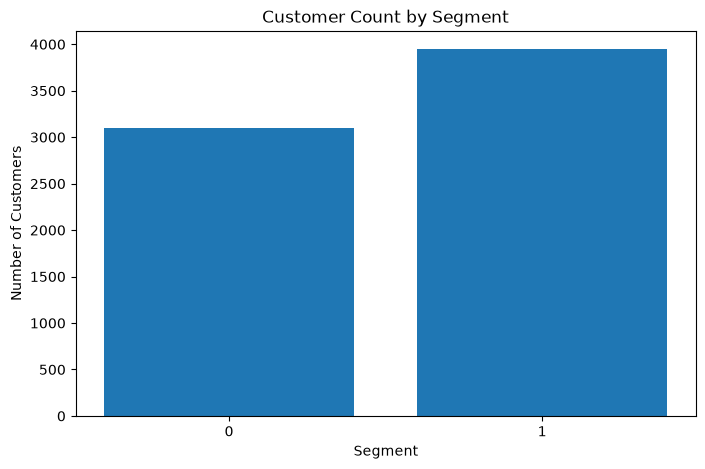

In [17]:
segment_sizes = (
    working_df["Segment"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    segment_sizes.index.astype(str),
    segment_sizes.values
)

plt.title("Customer Count by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

# 16. Visualize the segment profiles

A heatmap makes it easier to compare the relative behaviour of segments.

We standardize the profile values only for visualization.

The original business values remain available in `segment_profile`.

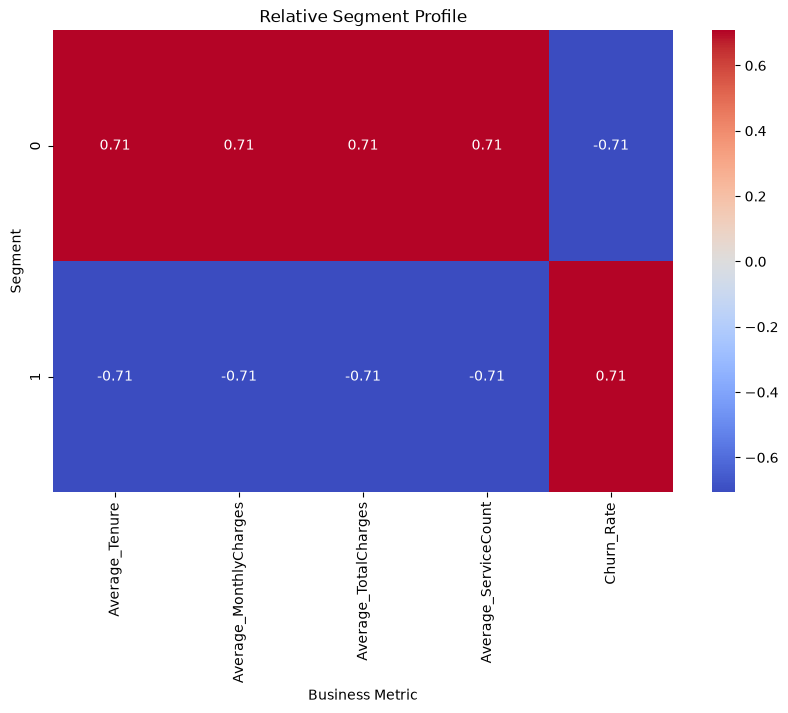

In [18]:
profile_for_heatmap = segment_profile[
    [
        "Average_Tenure",
        "Average_MonthlyCharges",
        "Average_TotalCharges",
        "Average_ServiceCount",
        "Churn_Rate"
    ]
].copy()

profile_for_heatmap = (
    profile_for_heatmap
    - profile_for_heatmap.mean()
) / profile_for_heatmap.std()

plt.figure(figsize=(10, 6))

sns.heatmap(
    profile_for_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Relative Segment Profile"
)

plt.xlabel("Business Metric")
plt.ylabel("Segment")

plt.show()

# 17. Give the segments business-friendly names

KMeans creates numerical labels.

The names below should be based on the actual profile values rather than invented before seeing the data.

The exact names may need adjustment after reviewing the generated profile.

Examples of useful business language:

- New / Low-Engagement Customers
- High-Value Customers
- Long-Term Core Customers
- High-Cost / At-Risk Customers

The labels are descriptions, not machine-learning outputs.

In [19]:
segment_profile_sorted = segment_profile.sort_values(
    "Churn_Rate",
    ascending=False
)

segment_profile_sorted

,Customers,Customer_Percentage,Average_Tenure,Average_MonthlyCharges,Average_TotalCharges,Average_ServiceCount,Churn_Rate
Segment,,,,,,,
1,3946,56.027261,20.07,46.38,747.98,0.69,30.16
0,3097,43.972739,48.04,88.19,4231.40,3.75,21.92


### Naming rule

Use the profile to determine the story:

- Low tenure + low service adoption → likely early-stage / low-engagement
- High monthly charges + high service adoption → potentially high-value
- High tenure + strong service adoption → mature / loyal relationship
- High charges + high churn rate → high-value risk or intervention segment

Do not force these names if the actual data tells a different story.

# 18. Connect segmentation with churn risk

This is where the two major parts of the project come together.

The clustering model creates customer groups.

The churn model estimates individual churn risk.

We can therefore ask:

> **Which customer segments contain the highest concentration of churn?**

This is more actionable than looking at churn probability alone.

In [20]:
segment_churn = (
    working_df
    .groupby("Segment")
    .agg(
        Customers=("customerID", "count"),
        Churned_Customers=(
            "Churn",
            lambda values: (
                values == "Yes"
            ).sum()
        ),
        Churn_Rate=(
            "Churn",
            lambda values: (
                values == "Yes"
            ).mean() * 100
        ),
        Average_Tenure=("tenure", "mean"),
        Average_MonthlyCharges=(
            "MonthlyCharges",
            "mean"
        ),
        Average_ServiceCount=(
            "ServiceCount",
            "mean"
        )
    )
    .round(2)
)

segment_churn

,Customers,Churned_Customers,Churn_Rate,Average_Tenure,Average_MonthlyCharges,Average_ServiceCount
Segment,,,,,,
0,3097,679,21.92,48.04,88.19,3.75
1,3946,1190,30.16,20.07,46.38,0.69


# 19. Compare churn rate across segments

A segment with a high churn rate deserves different attention from a segment with low churn.

However, remember that churn rate alone does not determine business priority.

A small high-churn segment may represent less total lost revenue than a large moderate-risk segment.

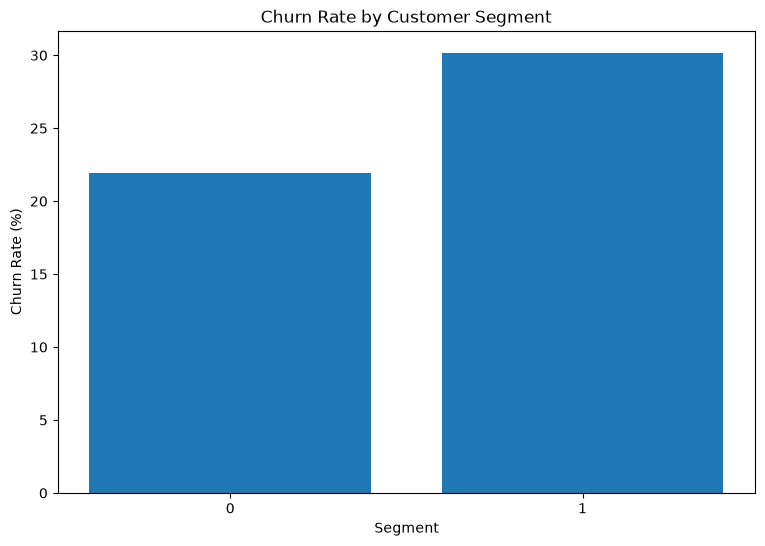

In [21]:
plt.figure(figsize=(9, 6))

plt.bar(
    segment_churn.index.astype(str),
    segment_churn["Churn_Rate"]
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

# 20. Estimate segment-level monthly revenue exposure

A useful business view is not only:

> Which segment churns the most?

but also:

> Which segment represents the largest amount of monthly revenue that is potentially at risk?

We calculate an illustrative exposure:

```text
Monthly Revenue Exposure = Number of churned customers × Average Monthly Charges
```

This is not the same as predicted future loss.

It is simply a useful prioritization indicator.

In [22]:
segment_business_value = (
    working_df
    .groupby("Segment")
    .agg(
        Customers=("customerID", "count"),
        Churned_Customers=(
            "Churn",
            lambda values: (
                values == "Yes"
            ).sum()
        ),
        Average_MonthlyCharges=(
            "MonthlyCharges",
            "mean"
        ),
        Churn_Rate=(
            "Churn",
            lambda values: (
                values == "Yes"
            ).mean() * 100
        )
    )
)

segment_business_value[
    "Illustrative_Monthly_Revenue_Exposure"
] = (
    segment_business_value["Churned_Customers"]
    * segment_business_value["Average_MonthlyCharges"]
)

segment_business_value.round(2)

,Customers,Churned_Customers,Average_MonthlyCharges,Churn_Rate,Illustrative_Monthly_Revenue_Exposure
Segment,,,,,
0,3097,679,88.19,21.92,59878.39
1,3946,1190,46.38,30.16,55188.77


# 21. Identify priority segments

We create a simple prioritization view.

This is not a machine-learning score.

It is a business framework combining:

- segment size
- churn rate
- monthly revenue exposure

The purpose is to decide where a retention team could investigate first.

In [23]:
priority_table = segment_business_value.copy()

priority_table["Priority"] = "Review"

high_churn_threshold = (
    priority_table["Churn_Rate"].median()
)

high_exposure_threshold = (
    priority_table[
        "Illustrative_Monthly_Revenue_Exposure"
    ].median()
)

priority_table.loc[
    (
        priority_table["Churn_Rate"]
        >= high_churn_threshold
    )
    &
    (
        priority_table[
            "Illustrative_Monthly_Revenue_Exposure"
        ]
        >= high_exposure_threshold
    ),
    "Priority"
] = "High Priority"

priority_table.loc[
    (
        priority_table["Churn_Rate"]
        < high_churn_threshold
    )
    &
    (
        priority_table[
            "Illustrative_Monthly_Revenue_Exposure"
        ]
        < high_exposure_threshold
    ),
    "Priority"
] = "Lower Priority"

priority_table.round(2)

,Customers,Churned_Customers,Average_MonthlyCharges,Churn_Rate,Illustrative_Monthly_Revenue_Exposure,Priority
Segment,,,,,,
0,3097,679,88.19,21.92,59878.39,Review
1,3946,1190,46.38,30.16,55188.77,Review


# 22. Create an actionable segment strategy

The exact strategy should follow the observed profile.

The table below provides a framework rather than pretending that one action fits every customer.

| Segment characteristic | Possible business action |
|---|---|
| High churn + high monthly charges | Priority retention / proactive outreach |
| High churn + low tenure | Improve onboarding and early-life experience |
| High service adoption + high value | Loyalty and retention offers |
| Long tenure + low churn | Protect relationship and avoid unnecessary discounts |
| Low engagement + low service adoption | Education, bundles, or cross-sell |
| Small high-risk segment | Targeted intervention rather than broad campaign |

The important point is that segmentation turns model output into **different business actions for different customer groups**.

# 23. Final segmentation dataset

We now create a customer-level table containing the information needed for downstream analysis.

This can later be connected to the churn model's predicted probability.

In [24]:
customer_segments = working_df[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "ServiceCount",
        "Contract",
        "InternetService",
        "Churn",
        "Segment"
    ]
].copy()

customer_segments.head()

,customerID,tenure,MonthlyCharges,TotalCharges,ServiceCount,Contract,InternetService,Churn,Segment
0,7590-VHVEG,1,29.85,29.85,1,Month-to-month,DSL,No,1
1,5575-GNVDE,34,56.95,1889.50,2,One year,DSL,No,1
2,3668-QPYBK,2,53.85,108.15,2,Month-to-month,DSL,Yes,1
3,7795-CFOCW,45,42.30,1840.75,3,One year,DSL,No,0
4,9237-HQITU,2,70.70,151.65,0,Month-to-month,Fiber optic,Yes,1


# 24. Save the segmentation output

The raw data is never overwritten.

We save only the derived customer segmentation output into the processed-data directory.

In [25]:
PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SEGMENT_OUTPUT_PATH = (
    PROCESSED_DATA_DIR
    / "customer_segments.csv"
)

customer_segments.to_csv(
    SEGMENT_OUTPUT_PATH,
    index=False
)

print(
    "Saved segmentation output to:"
)

print(
    SEGMENT_OUTPUT_PATH
)

Saved segmentation output to:
d:\Projects\Customer Churn Segmentation\data\processed\customer_segments.csv


# 25. Save the clustering model and scaler

The scaler and KMeans model are required if new customers need to be assigned to an existing segment later.

This is an important production consideration:

> **Do not fit a new scaler or new clusters every time a new customer arrives.**

The production system should load the existing scaler and KMeans model and use them to assign the customer to the existing segmentation structure.

In [26]:
import joblib

SEGMENT_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

SEGMENT_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SCALER_PATH = (
    SEGMENT_MODEL_DIR
    / "segmentation_scaler.joblib"
)

KMEANS_PATH = (
    SEGMENT_MODEL_DIR
    / "customer_segmentation_kmeans.joblib"
)

joblib.dump(
    scaler,
    SCALER_PATH
)

joblib.dump(
    final_kmeans,
    KMEANS_PATH
)

print("Saved:")
print(SCALER_PATH)
print(KMEANS_PATH)

Saved:
d:\Projects\Customer Churn Segmentation\models\segmentation_scaler.joblib
d:\Projects\Customer Churn Segmentation\models\customer_segmentation_kmeans.joblib


# 26. Final conclusions

## What we learned

### Segmentation

We created customer segments using:

- tenure
- monthly charges
- service adoption

without using the churn target during clustering.

### Cluster selection

We compared multiple cluster counts using:

- Elbow Method
- Silhouette Score
- Business interpretability

### Customer profiling

Each segment was profiled using:

- customer size
- tenure
- monthly charges
- total charges
- service adoption
- churn rate
- contract behaviour
- internet service behaviour

### Business analysis

We connected segments with:

- churn behaviour
- customer value
- illustrative revenue exposure
- retention priorities

## Final project insight

The two models answer different questions:

**Churn Prediction**

> Which individual customers are likely to leave?

**Customer Segmentation**

> What kind of customers are they?

Together:

> **Who is likely to churn, what type of customer are they, and what business action should we consider?**

That combination is much more useful than presenting a standalone classification model.

## Next stage

The machine-learning analysis is now substantially complete.

The next phase is productionization:

- reusable preprocessing code
- reusable prediction code
- final model pipeline
- FastAPI endpoint
- request validation
- automated tests
- Docker
- deployment
- GitHub documentation

> **The objective now shifts from “Can we build the model?” to “Can someone reliably use the model?”**